# Liður 1

In [ ]:
import pandas as pd

# Gögn fyrir Svartá í Skagafirði (ID 84)
data = {
    "id": 84,
    "area_calc": 390.56,
    "elev_mean": 522.005,
    "elev_med": 586.495,
    "elev_ran": 1091.341,
    "elev_std": 221.838,
    "slope_mean": 152.188,
    "p_mean": 2.32,
    "ref_et_mean": 0.66,
    "aridity": 0.29,
    "frac_snow": 0.55,
    "q_mean": 2.472,
    "runoff_ratio": 1.039,
    "baseflow_index_ladson": 0.699,
    "Q95": 1.223,
    "Q5": 5.656,
    "agr_fra": 0.362,
    "bare_fra": 0.069,
    "forest_fra": 0.0,
    "glac_fra": 0.0,
    "lake_fra": 0.0,
    "scrub_fra": 0.551,
    "wetl_fra": 0.019,
    "urban_fra": 0.0
}

row = pd.Series(data)

# Tafla fyrir skýrslu
summary = pd.DataFrame({
    "Breyta": [
        "Flatarmál",
        "Meðalhæð",
        "Miðhæð",
        "Hæðarsvið",
        "Staðalfrávik hæðar",
        "Meðalhalli",
        "Meðalúrkoma",
        "Meðal PET",
        "Þurrkstuðull",
        "Hlutfall snjóúrkomu",
        "Meðalrennsli",
        "Runoff ratio",
        "Baseflow Index",
        "Q95",
        "Q5",
        "Landbúnaðarland",
        "Bert land",
        "Skógur",
        "Jöklar",
        "Vötn",
        "Kjarr/mólendi",
        "Votlendi",
        "Þéttbýli"
    ],
    "Gildi": [
        row["area_calc"],
        row["elev_mean"],
        row["elev_med"],
        row["elev_ran"],
        row["elev_std"],
        row["slope_mean"],
        row["p_mean"],
        row["ref_et_mean"],
        row["aridity"],
        row["frac_snow"],
        row["q_mean"],
        row["runoff_ratio"],
        row["baseflow_index_ladson"],
        row["Q95"],
        row["Q5"],
        row["agr_fra"],
        row["bare_fra"],
        row["forest_fra"],
        row["glac_fra"],
        row["lake_fra"],
        row["scrub_fra"],
        row["wetl_fra"],
        row["urban_fra"]
    ],
    "Eining": [
        "km²",
        "m y.s.",
        "m y.s.",
        "m",
        "m",
        "m/km",
        "mm/dag",
        "mm/dag",
        "-",
        "hlutfall",
        "mm/dag",
        "-",
        "-",
        "mm/dag",
        "mm/dag",
        "hlutfall",
        "hlutfall",
        "hlutfall",
        "hlutfall",
        "hlutfall",
        "hlutfall",
        "hlutfall",
        "hlutfall"
    ]
})

summary["Gildi"] = summary["Gildi"].round(3)

print(summary.to_string(index=False))

             Breyta    Gildi   Eining
          Flatarmál  390.560      km²
           Meðalhæð  522.005   m y.s.
             Miðhæð  586.495   m y.s.
          Hæðarsvið 1091.341        m
 Staðalfrávik hæðar  221.838        m
         Meðalhalli  152.188     m/km
        Meðalúrkoma    2.320   mm/dag
          Meðal PET    0.660   mm/dag
       Þurrkstuðull    0.290        -
Hlutfall snjóúrkomu    0.550 hlutfall
       Meðalrennsli    2.472   mm/dag
       Runoff ratio    1.039        -
     Baseflow Index    0.699        -
                Q95    1.223   mm/dag
                 Q5    5.656   mm/dag
    Landbúnaðarland    0.362 hlutfall
          Bert land    0.069 hlutfall
             Skógur    0.000 hlutfall
             Jöklar    0.000 hlutfall
               Vötn    0.000 hlutfall
      Kjarr/mólendi    0.551 hlutfall
           Votlendi    0.019 hlutfall
           Þéttbýli    0.000 hlutfall


Liður 2


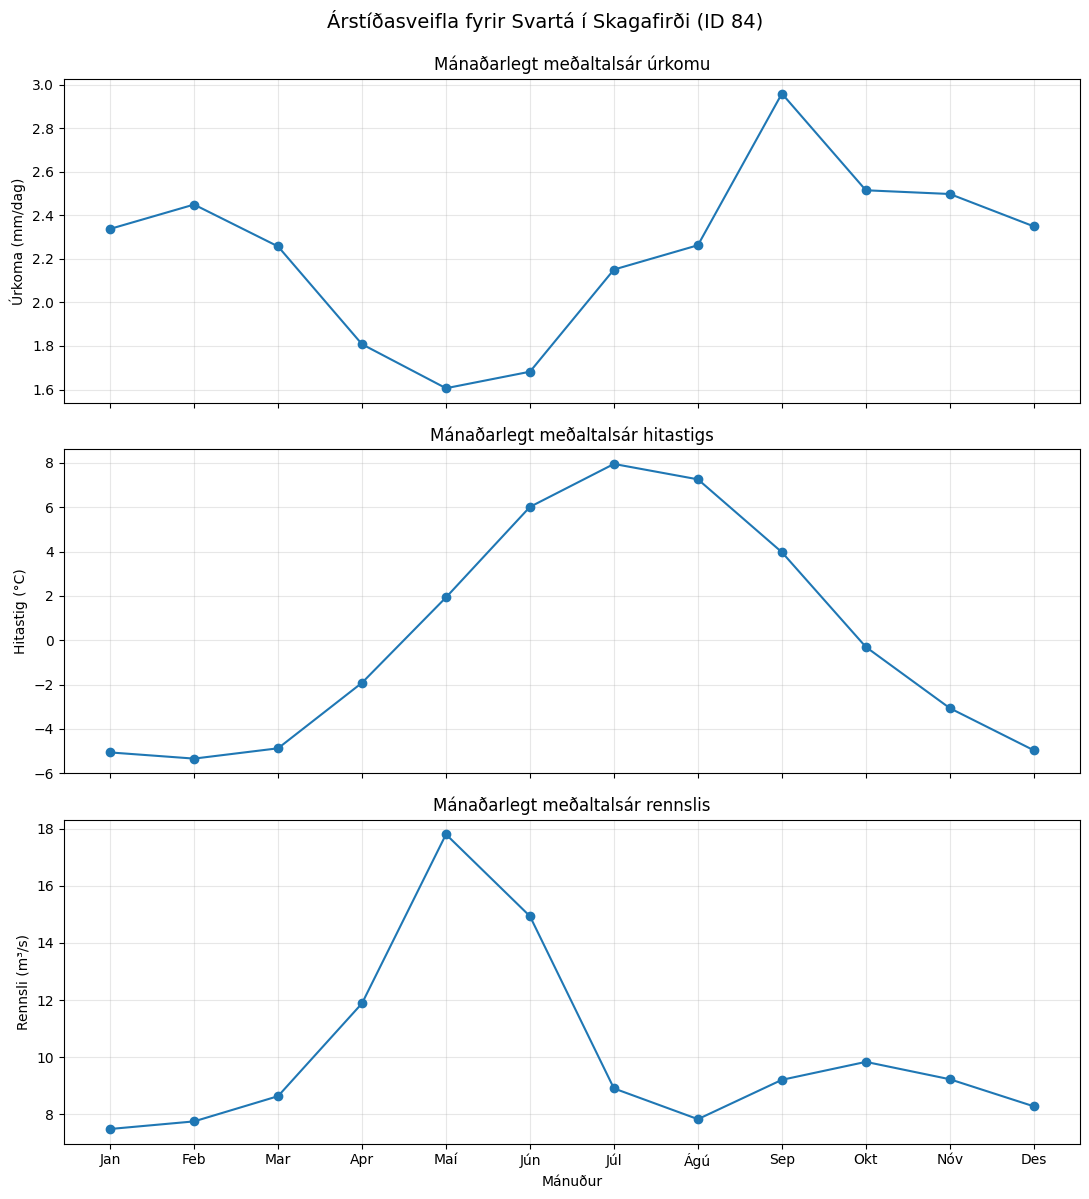

    month  prec_carra  2m_temp_carra   qobs
0       1        2.34          -5.06   7.49
1       2        2.45          -5.34   7.76
2       3        2.26          -4.87   8.64
3       4        1.81          -1.92  11.89
4       5        1.61           1.93  17.80
5       6        1.68           6.02  14.93
6       7        2.15           7.95   8.91
7       8        2.26           7.26   7.83
8       9        2.96           3.97   9.21
9      10        2.51          -0.30   9.84
10     11        2.50          -3.06   9.23
11     12        2.35          -4.96   8.28


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Google Sheets upplýsingar ---
sheet_id = "1dld6f07WhVLpz-iDmhCejRfWrv8v5hDKFGPKrWkvFdI"
gid_met = "274008059"
gid_q = "1766120044"

url_met = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid_met}"
url_q = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid_q}"

# --- Lesa veðurgögn ---
met = pd.read_csv(url_met)

met["date"] = pd.to_datetime({
    "year": met["YYYY"],
    "month": met["MM"],
    "day": met["DD"]
})

met = met[["date", "prec_carra", "2m_temp_carra"]].dropna()

# --- Lesa rennslisgögn ---
q = pd.read_csv(url_q)

q["date"] = pd.to_datetime({
    "year": q["YYYY"],
    "month": q["MM"],
    "day": q["DD"]
})

q = q[["date", "qobs"]].dropna()

# --- Sameina gögn ---
df = pd.merge(met, q, on="date", how="inner")

# --- Bæta við mánuði ---
df["month"] = df["date"].dt.month

# --- Reikna mánaðarlegt meðaltalsár ---
monthly = df.groupby("month", as_index=False).agg({
    "prec_carra": "mean",
    "2m_temp_carra": "mean",
    "qobs": "mean"
})

# Mánaðarheiti
month_names = ["Jan", "Feb", "Mar", "Apr", "Maí", "Jún",
               "Júl", "Ágú", "Sep", "Okt", "Nóv", "Des"]

# --- Teikna 3 gröf ---
fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)

# 1) Úrkoma
axes[0].plot(monthly["month"], monthly["prec_carra"], marker="o")
axes[0].set_ylabel("Úrkoma (mm/dag)")
axes[0].set_title("Mánaðarlegt meðaltalsár úrkomu")
axes[0].grid(True, alpha=0.3)

# 2) Hitastig
axes[1].plot(monthly["month"], monthly["2m_temp_carra"], marker="o")
axes[1].set_ylabel("Hitastig (°C)")
axes[1].set_title("Mánaðarlegt meðaltalsár hitastigs")
axes[1].grid(True, alpha=0.3)

# 3) Rennsli
axes[2].plot(monthly["month"], monthly["qobs"], marker="o")
axes[2].set_ylabel("Rennsli (m³/s)")
axes[2].set_title("Mánaðarlegt meðaltalsár rennslis")
axes[2].grid(True, alpha=0.3)

# X-ás
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(month_names)
axes[2].set_xlabel("Mánuður")

plt.suptitle("Árstíðasveifla fyrir Svartá í Skagafirði (ID 84)", fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

# Skoða töfluna líka
print(monthly.round(2))

Liður 3

Fjöldi daga: 10957
Tímabil: 1993-10-01 til 2023-09-30
BFI = 0.753

Besti recession-kafli:
Frá: 2017-02-27
Til: 2017-03-04
Lengd: 6 dagar
k = 0.0187 1/dag
a = 0.9815
R² = 0.999


/tmp/ipykernel_2442/3197257862.py:95: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["qb"].sum() / g["qobs"].sum())


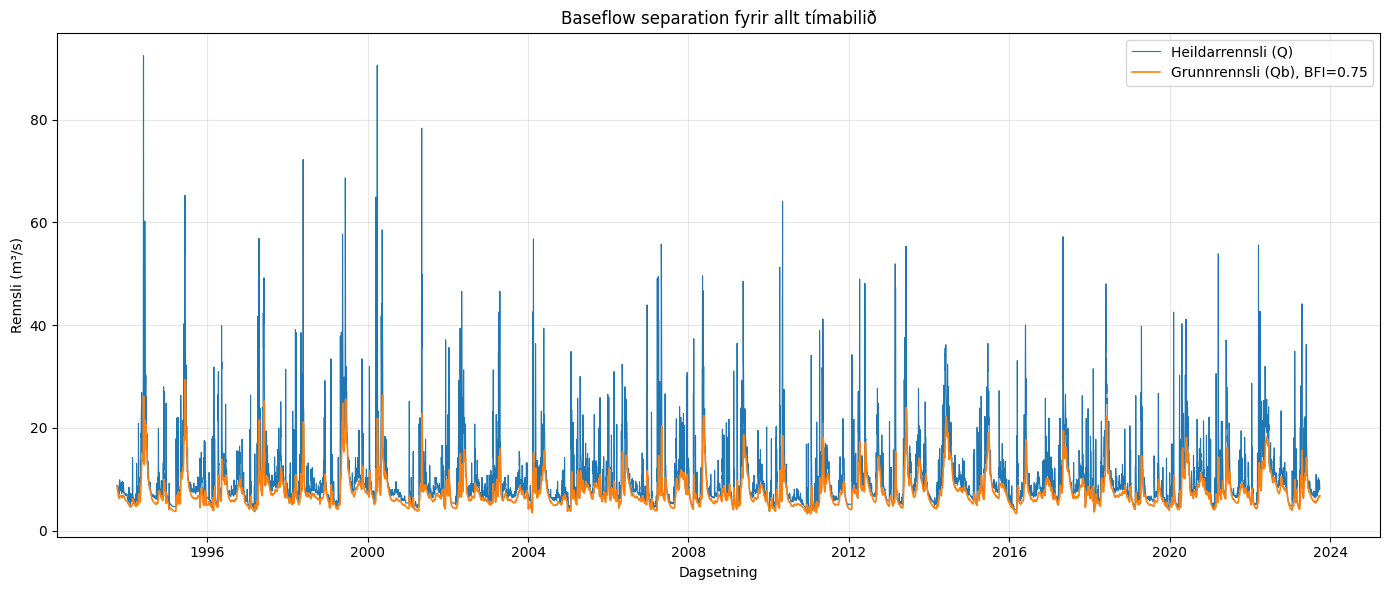

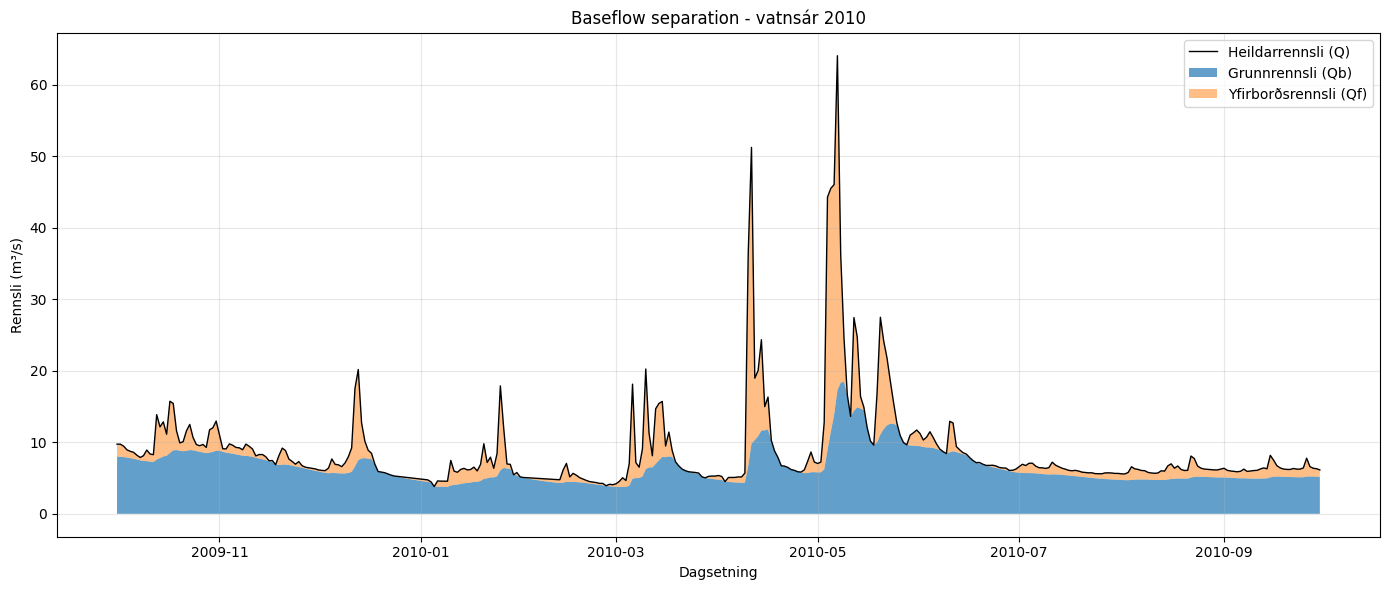

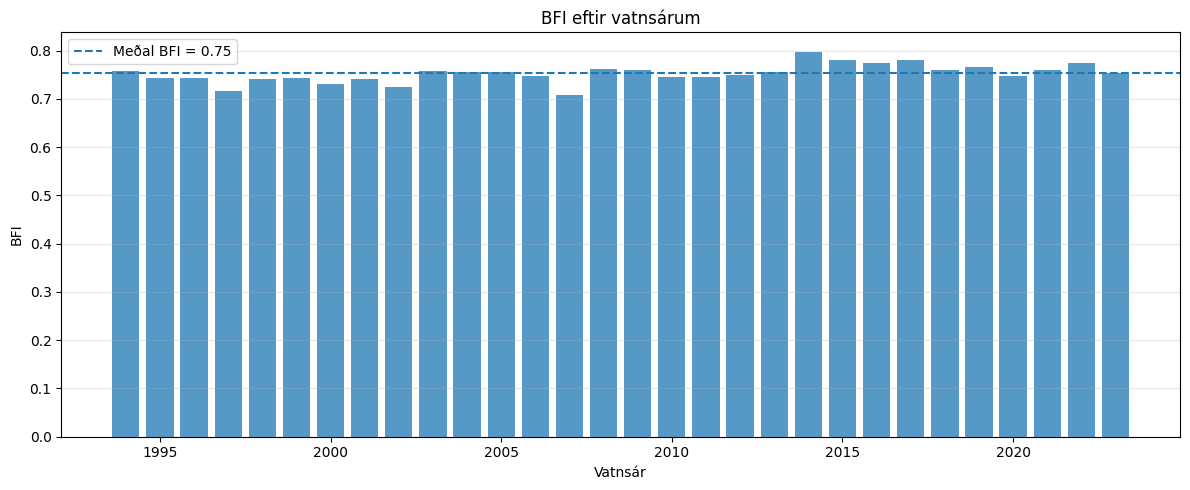

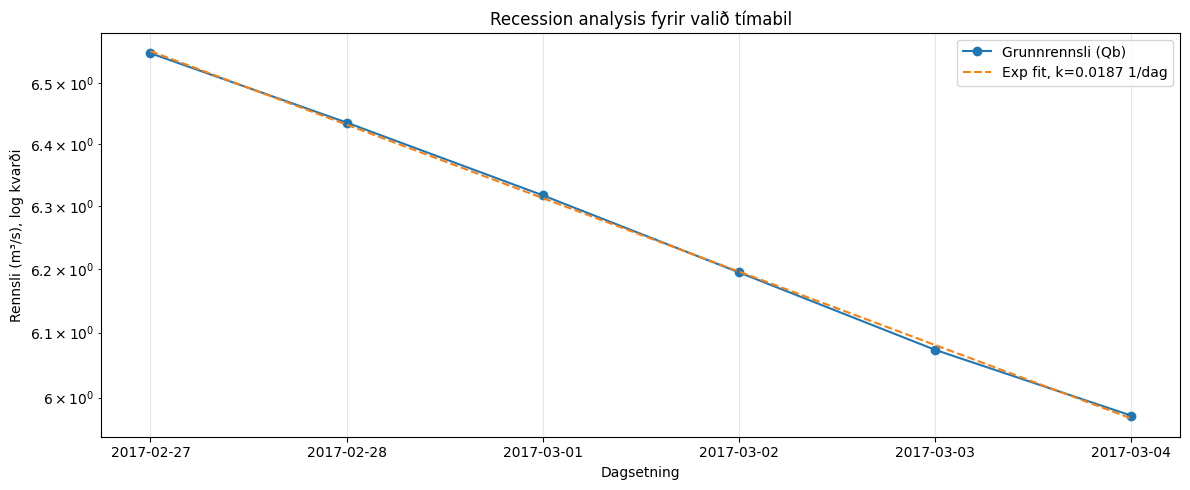

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. STILLINGAR
# =========================================================

sheet_id = "1dld6f07WhVLpz-iDmhCejRfWrv8v5hDKFGPKrWkvFdI" # Corrected sheet ID
gid_q = "1766120044"      # þetta er staðfest
gid_met = "274008059"     # Corrected GID for weather data

def load_csv_from_gsheet(sheet_id, gid):
    url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
    return pd.read_csv(url)

# =========================================================
# 2. LESA INN GÖGN
# =========================================================

df_q = load_csv_from_gsheet(sheet_id, gid_q)
df_met = load_csv_from_gsheet(sheet_id, gid_met)

# dagsetningar
for df in [df_q, df_met]:
    df["date"] = pd.to_datetime({
        "year": df["YYYY"],
        "month": df["MM"],
        "day": df["DD"]
    }, errors="coerce")

# velja rétta dálka
df_q = df_q[["date", "qobs", "qc_flag"]].copy()
df_met = df_met[["date", "prec", "2m_temp_mean"]].copy()

# merge
df = pd.merge(df_q, df_met, on="date", how="inner")

# hreinsa
df["qobs"] = pd.to_numeric(df["qobs"], errors="coerce")
df["prec"] = pd.to_numeric(df["prec"], errors="coerce")
df["2m_temp_mean"] = pd.to_numeric(df["2m_temp_mean"], errors="coerce")
df["qc_flag"] = pd.to_numeric(df["qc_flag"], errors="coerce")

df = df.dropna(subset=["date", "qobs"]).copy()
df = df[df["qobs"] > 0].copy()

# ef þú vilt bara nota góða quality daga
# þetta má laga eftir því hvað qc_flag merkir í gögnunum
# df = df[df["qc_flag"] == 40].copy()

# verkefnistímabil
df = df[(df["date"] >= "1993-10-01") & (df["date"] <= "2023-09-30")].copy()

df = df.sort_values("date").reset_index(drop=True)

# vatnsár
df["water_year"] = df["date"].dt.year
df.loc[df["date"].dt.month >= 10, "water_year"] += 1

print("Fjöldi daga:", len(df))
print("Tímabil:", df["date"].min().date(), "til", df["date"].max().date())

# =========================================================
# 3. ECKHARDT BASEFLOW FILTER
# =========================================================

def eckhardt_baseflow(q, alpha=0.98, BFImax=0.80):
    q = np.asarray(q, dtype=float)
    qb = np.zeros(len(q))
    qb[0] = q[0]

    for i in range(1, len(q)):
        qb[i] = (
            ((1 - BFImax) * alpha * qb[i-1] + (1 - alpha) * BFImax * q[i])
            / (1 - alpha * BFImax)
        )
        qb[i] = min(qb[i], q[i])
        qb[i] = max(qb[i], 0.0)

    return qb

df["qb"] = eckhardt_baseflow(df["qobs"].values, alpha=0.98, BFImax=0.80)
df["qf"] = df["qobs"] - df["qb"]

# =========================================================
# 4. BFI
# =========================================================

BFI = df["qb"].sum() / df["qobs"].sum()
print(f"BFI = {BFI:.3f}")

annual_bfi = (
    df.groupby("water_year")
      .apply(lambda g: g["qb"].sum() / g["qobs"].sum())
      .reset_index(name="BFI")
)

# =========================================================
# 5. RECESSION ANALYSIS
# =========================================================

def find_recession_segments(df, min_length=5, max_precip=0.1, max_temp=0.5):
    segments = []
    start = None

    q = df["qb"].values
    p = df["prec"].values
    t = df["2m_temp_mean"].values

    for i in range(1, len(df)):
        cond = (
            (q[i] < q[i-1]) and
            (np.isnan(p[i]) or p[i] <= max_precip) and
            (np.isnan(t[i]) or t[i] <= max_temp)
        )

        if cond:
            if start is None:
                start = i - 1
        else:
            if start is not None:
                end = i - 1
                if end - start + 1 >= min_length:
                    segments.append((start, end))
                start = None

    if start is not None:
        end = len(df) - 1
        if end - start + 1 >= min_length:
            segments.append((start, end))

    return segments

segments = find_recession_segments(df, min_length=5, max_precip=0.1, max_temp=0.5)

def fit_recession(segment_df):
    seg = segment_df.copy()
    seg = seg[seg["qb"] > 0].copy()

    if len(seg) < 3:
        return None

    seg["t"] = np.arange(len(seg), dtype=float)
    seg["lnQ"] = np.log(seg["qb"])

    slope, intercept = np.polyfit(seg["t"], seg["lnQ"], 1)
    seg["lnQ_fit"] = intercept + slope * seg["t"]
    seg["Q_fit"] = np.exp(seg["lnQ_fit"])

    k = -slope
    a = np.exp(-k)

    ss_res = np.sum((seg["lnQ"] - seg["lnQ_fit"])**2)
    ss_tot = np.sum((seg["lnQ"] - seg["lnQ"].mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return {
        "k": k,
        "a": a,
        "r2": r2,
        "segment": seg
    }

results = []
for start, end in segments:
    seg = df.iloc[start:end+1].copy()
    fit = fit_recession(seg)
    if fit is not None:
        results.append({
            "start": seg["date"].iloc[0],
            "end": seg["date"].iloc[-1],
            "n_days": len(seg),
            "k": fit["k"],
            "a": fit["a"],
            "r2": fit["r2"],
            "segment": fit["segment"]
        })

if len(results) > 0:
    results = sorted(results, key=lambda x: (x["r2"], x["n_days"]), reverse=True)
    best = results[0]

    print("\nBesti recession-kafli:")
    print("Frá:", best["start"].date())
    print("Til:", best["end"].date())
    print("Lengd:", best["n_days"], "dagar")
    print(f"k = {best['k']:.4f} 1/dag")
    print(f"a = {best['a']:.4f}")
    print(f"R² = {best['r2']:.3f}")
else:
    best = None
    print("Enginn hentugur recession-kafli fannst.")

# =========================================================
# 6. MYNDIR
# =========================================================

plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["qobs"], label="Heildarrennsli (Q)", linewidth=0.8)
plt.plot(df["date"], df["qb"], label=f"Grunnrennsli (Qb), BFI={BFI:.2f}", linewidth=1.2)
plt.title("Baseflow separation fyrir allt tímabilið")
plt.xlabel("Dagsetning")
plt.ylabel("Rennsli (m³/s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

example_water_year = 2010
dff = df[df["water_year"] == example_water_year].copy()

if len(dff) > 0:
    plt.figure(figsize=(14, 6))
    plt.plot(dff["date"], dff["qobs"], color="black", linewidth=1.0, label="Heildarrennsli (Q)")
    plt.fill_between(dff["date"], 0, dff["qb"], alpha=0.7, label="Grunnrennsli (Qb)")
    plt.fill_between(dff["date"], dff["qb"], dff["qobs"], alpha=0.5, label="Yfirborðsrennsli (Qf)")
    plt.title(f"Baseflow separation - vatnsár {example_water_year}")
    plt.xlabel("Dagsetning")
    plt.ylabel("Rennsli (m³/s)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(12, 5))
plt.bar(annual_bfi["water_year"], annual_bfi["BFI"], alpha=0.75)
plt.axhline(BFI, linestyle="--", linewidth=1.5, label=f"Meðal BFI = {BFI:.2f}")
plt.title("BFI eftir vatnsárum")
plt.xlabel("Vatnsár")
plt.ylabel("BFI")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

if best is not None:
    seg = best["segment"]

    plt.figure(figsize=(12, 5))
    plt.plot(seg["date"], seg["qb"], "o-", label="Grunnrennsli (Qb)")
    plt.plot(seg["date"], seg["Q_fit"], "--", label=f"Exp fit, k={best['k']:.4f} 1/dag")
    plt.yscale("log")
    plt.title("Recession analysis fyrir valið tímabil")
    plt.xlabel("Dagsetning")
    plt.ylabel("Rennsli (m³/s), log kvarði")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

liður 5

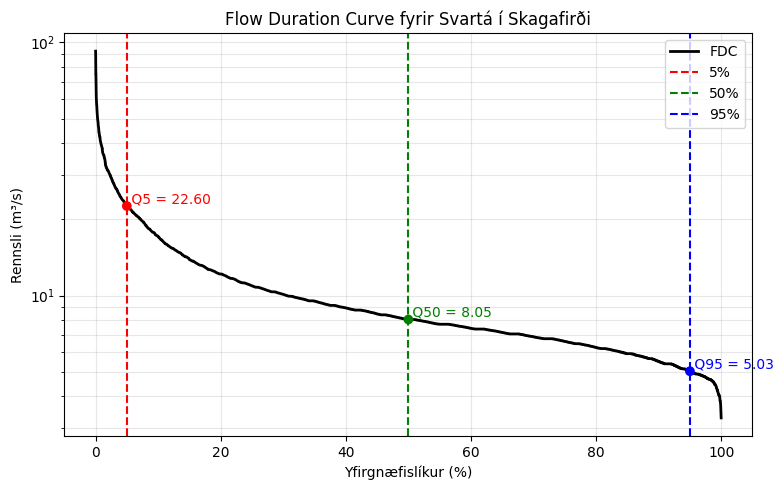

Q5  = 22.60 m³/s
Q50 = 8.05 m³/s
Q95 = 5.03 m³/s


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Raða rennslisgögnum frá hæsta til lægsta
q_sorted = df["qobs"].sort_values(ascending=False).reset_index(drop=True)

# Exceedance probability (%)
n = len(q_sorted)
rank = np.arange(1, n + 1)
exceedance = rank / (n + 1) * 100

# Q-gildi
Q5 = np.percentile(df["qobs"], 95)
Q50 = np.percentile(df["qobs"], 50)
Q95 = np.percentile(df["qobs"], 5)

plt.figure(figsize=(8, 5))

# FDC ferill
plt.plot(exceedance, q_sorted, color="black", linewidth=2, label="FDC")

# Lóðréttar línur við 5%, 50%, 95%
plt.axvline(5, color="red", linestyle="--", linewidth=1.5, label="5%")
plt.axvline(50, color="green", linestyle="--", linewidth=1.5, label="50%")
plt.axvline(95, color="blue", linestyle="--", linewidth=1.5, label="95%")

# Punktar á ferlinum
plt.scatter([5, 50, 95], [Q5, Q50, Q95],
            color=["red", "green", "blue"], zorder=5)

# Texti við punktana
plt.text(5, Q5, f" Q5 = {Q5:.2f}", color="red", va="bottom")
plt.text(50, Q50, f" Q50 = {Q50:.2f}", color="green", va="bottom")
plt.text(95, Q95, f" Q95 = {Q95:.2f}", color="blue", va="bottom")

plt.xlabel("Yfirgnæfislíkur (%)")
plt.ylabel("Rennsli (m³/s)")
plt.title("Flow Duration Curve fyrir Svartá í Skagafirði")
plt.yscale("log")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Q5  = {Q5:.2f} m³/s")
print(f"Q50 = {Q50:.2f} m³/s")
print(f"Q95 = {Q95:.2f} m³/s")

liður 6

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gumbel_r

# --- LESA RENNSLI OG UNDIRBÚA GÖGN ---
# Til að laga "NameError: name 'df' is not defined" villuna þarf að skilgreina 'df' DataFrame-ið.
# Þessi kóði er tekinn úr fyrri hlutum verkefnisins þar sem 'df' er búið til með rennslisgögnunum.
sheet_id = "1dld6f07WhVLpz-iDmhCejRfWrv8v5hDKFGPKrWkvFdI"
gid_q = "1766120044"

url_q = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid_q}"

df = pd.read_csv(url_q)

# Búa til 'date' dálk út frá ári, mánuði og degi
df["date"] = pd.to_datetime({
    "year": df["YYYY"],
    "month": df["MM"],
    "day": df["DD"]
})

# Halda aðeins 'date' og 'qobs' og fjarlægja línur með vantar gögnum
df = df[["date", "qobs"]].dropna().copy()

# Tryggja að gögnin séu í réttri tímaröð
df = df.sort_values("date").reset_index(drop=True)

# bæta við ári og mánuði
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# finna stærsta rennsli hvers árs
annual_max = df.loc[df.groupby("year")["qobs"].idxmax()].copy()

# halda bara því sem við þurfum
annual_max = annual_max[["year", "date", "month", "qobs"]].sort_values("year").reset_index(drop=True)

print(annual_max.head())
print("Fjöldi ára:", len(annual_max))


   year       date  month   qobs
0  1993 1993-10-25     10   9.89
1  1994 1994-05-30      5  92.41
2  1995 1995-06-12      6  65.23
3  1996 1996-05-10      5  39.93
4  1997 1997-04-16      4  56.87
Fjöldi ára: 31


In [ ]:
# gögn fyrir dreifingu
peaks = annual_max["qobs"].values

# passa Gumbel dreifingu
loc, scale = gumbel_r.fit(peaks)

# endurkomutímar
T = np.array([10, 50, 100])

# ekki-yfirgnæfislíkur
p = 1 - 1 / T

# hönnunargildi
Q10, Q50, Q100 = gumbel_r.ppf(p, loc=loc, scale=scale)

print(f"Q10  = {Q10:.2f} m3/s")
print(f"Q50  = {Q50:.2f} m3/s")
print(f"Q100 = {Q100:.2f} m3/s")

Q10  = 81.08 m3/s
Q50  = 108.07 m3/s
Q100 = 119.48 m3/s


Fjöldi daga: 10957
Tímabil: 1993-10-01 til 2023-09-30

Fjöldi árshámarksflóða: 30
   index  water_year       date  annual_peak  month  year
0      0        1994 1994-05-30        92.41      5  1994
1      1        1995 1995-06-12        65.23      6  1995
2      2        1996 1996-05-10        39.93      5  1996
3      3        1997 1997-04-16        56.87      4  1997
4      4        1998 1998-05-23        72.21      5  1998


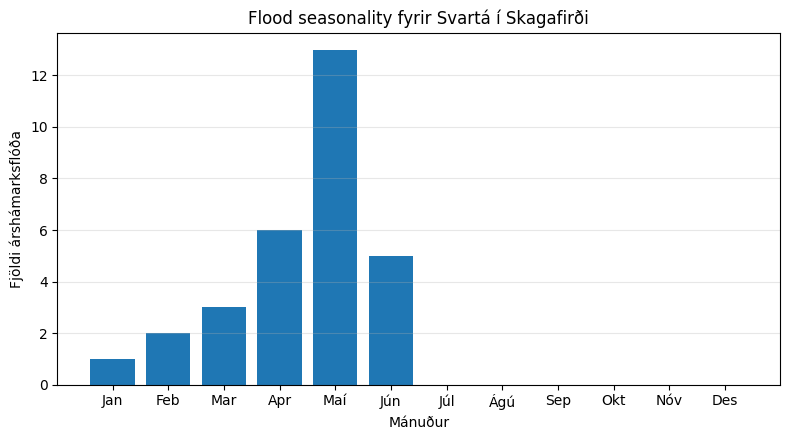

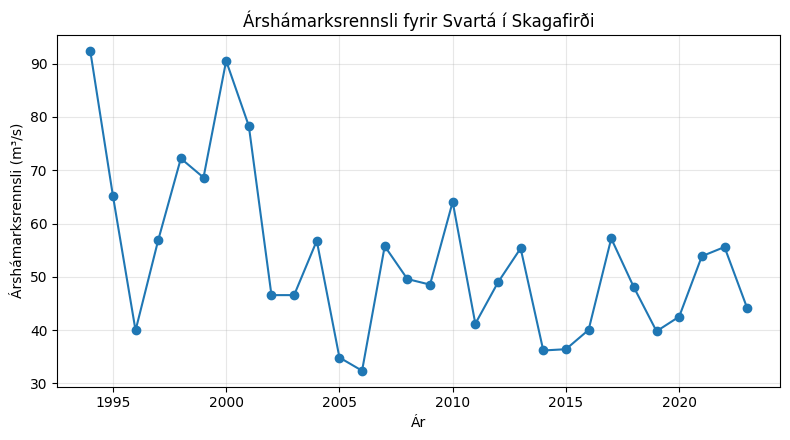


Samanburður dreifinga (lægra RMSE_log er betra):
 Distribution  RMSE_log
 Log-Normal 3  0.030761
Log-Pearson 3  0.031875
       Gumbel  0.037201

Besta dreifing samkvæmt RMSE_log: Log-Normal 3

Hönnunargildi:
 T_ár  Gumbel  Log-Normal 3  Log-Pearson 3
 10.0   71.78         73.86          73.88
 50.0   90.34         98.29          99.60
100.0   98.18        109.51         111.91

90% öryggisbil:
 T_ár  Gumbel_Q  Gumbel_LCL90  Gumbel_UCL90  LN3_Q  LN3_LCL90  LN3_UCL90  LP3_Q  LP3_LCL90  LP3_UCL90
 10.0     71.78         63.25         80.19  73.86      64.36      83.74  73.88      64.04      83.96
 50.0     90.34         77.58        102.82  98.29      78.29     125.60  99.60      77.60     140.45
100.0     98.18         83.64        112.36 109.51      83.68     148.61 111.91      82.29     176.67


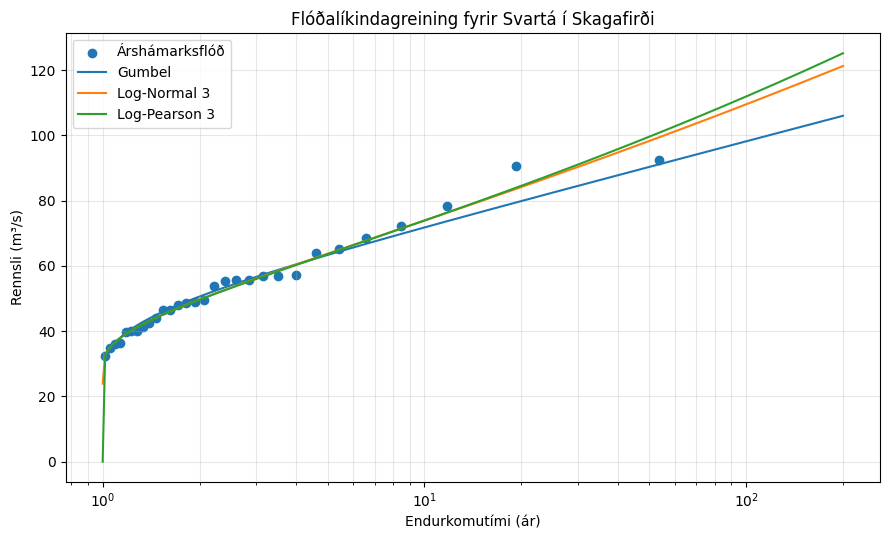

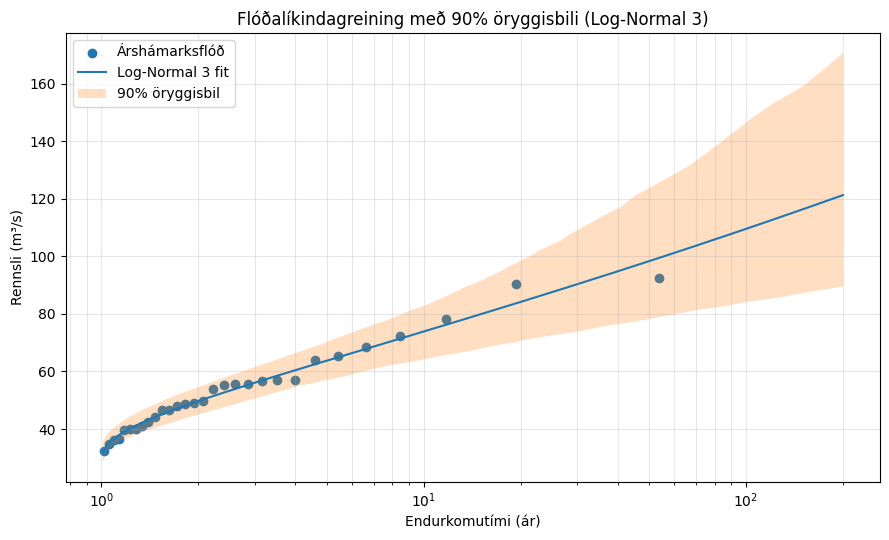


Vistaðar skrár:
- lidur6_annual_peak_flows.csv
- lidur6_fit_summary.csv
- lidur6_design_flows.csv
- lidur6_confidence_intervals.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gumbel_r, pearson3, norm
from scipy.optimize import minimize

# =========================================================
# 1. LESA INN GÖGN
# =========================================================

sheet_id = "1dld6f07WhVLpz-iDmhCejRfWrv8v5hDKFGPKrWkvFdI" # Corrected sheet ID
gid_q = "1766120044"

def load_csv_from_gsheet(sheet_id, gid):
    url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
    return pd.read_csv(url)

df = load_csv_from_gsheet(sheet_id, gid_q)

df["date"] = pd.to_datetime({
    "year": df["YYYY"],
    "month": df["MM"],
    "day": df["DD"]
}, errors="coerce")

df["qobs"] = pd.to_numeric(df["qobs"], errors="coerce")
df = df.dropna(subset=["date", "qobs"]).copy()
df = df[df["qobs"] > 0].copy()

# verkefnistímabil
df = df[(df["date"] >= "1993-10-01") & (df["date"] <= "2023-09-30")].copy()

# vatnsár
df["water_year"] = df["date"].dt.year
df.loc[df["date"].dt.month >= 10, "water_year"] += 1

df = df.sort_values("date").reset_index(drop=True)

print("Fjöldi daga:", len(df))
print("Tímabil:", df["date"].min().date(), "til", df["date"].max().date())

# =========================================================
# 2. ÁRSHÁMARKSRENNSLI (ANNUAL PEAK FLOWS)
# =========================================================

annual_max = (
    df.groupby("water_year", as_index=False)
      .apply(lambda g: g.loc[g["qobs"].idxmax(), ["date", "qobs"]], include_groups=False)
      .reset_index()
)

# ef pandas útgáfan býr til auka dálka
annual_max = annual_max.rename(columns={"qobs": "annual_peak"})
if "level_0" in annual_max.columns:
    annual_max = annual_max.drop(columns=["level_0"])
if "level_1" in annual_max.columns:
    annual_max = annual_max.drop(columns=["level_1"])

# tryggja að water_year haldist
if "water_year" not in annual_max.columns:
    annual_max["water_year"] = (
        df.groupby("water_year")["qobs"].idxmax().index.values
    )

annual_max["month"] = pd.to_datetime(annual_max["date"]).dt.month
annual_max["year"] = pd.to_datetime(annual_max["date"]).dt.year

print("\nFjöldi árshámarksflóða:", len(annual_max))
print(annual_max.head())

# =========================================================
# 3. FLOOD SEASONALITY
# =========================================================

month_counts = annual_max["month"].value_counts().sort_index()
month_names = ["Jan", "Feb", "Mar", "Apr", "Maí", "Jún",
               "Júl", "Ágú", "Sep", "Okt", "Nóv", "Des"]

counts_full = [month_counts.get(i, 0) for i in range(1, 13)]

plt.figure(figsize=(8, 4.5))
plt.bar(range(1, 13), counts_full)
plt.xticks(range(1, 13), month_names)
plt.xlabel("Mánuður")
plt.ylabel("Fjöldi árshámarksflóða")
plt.title("Flood seasonality fyrir Svartá í Skagafirði")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 4. LÍNURIT AF ÁRSHÁMARKSRENNSLI
# =========================================================

plt.figure(figsize=(8, 4.5))
plt.plot(annual_max["water_year"], annual_max["annual_peak"], marker="o")
plt.xlabel("Ár")
plt.ylabel("Árshámarksrennsli (m³/s)")
plt.title("Árshámarksrennsli fyrir Svartá í Skagafirði")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 5. GRINGORTEN PLOTTING POSITIONS
# =========================================================

def gringorten_return_periods(peaks):
    """
    Gringorten plotting positions fyrir árshámarksflóð.
    p = (m - 0.44) / (n + 0.12)
    T = 1 / (1 - p)
    þar sem m er rank með minnsta gildi fyrst.
    """
    x = np.sort(np.asarray(peaks, dtype=float))
    n = len(x)
    m = np.arange(1, n + 1)
    p_nonexceed = (m - 0.44) / (n + 0.12)
    T = 1.0 / (1.0 - p_nonexceed)
    return x, T, p_nonexceed

peaks = annual_max["annual_peak"].values
x_sorted, T_emp, p_emp = gringorten_return_periods(peaks)

# =========================================================
# 6. FITT Á DREIFINGUM
# =========================================================

# ---- GUMBEL ----
gumbel_loc, gumbel_scale = gumbel_r.fit(peaks)

def q_gumbel(T):
    F = 1 - 1 / np.asarray(T, dtype=float)
    return gumbel_r.ppf(F, loc=gumbel_loc, scale=gumbel_scale)

# ---- LOG-NORMAL 3 ----
# X = xi + exp(Y), Y ~ N(mu, sigma)
# fit með hámarkslíkum

def fit_lognormal3(x):
    x = np.asarray(x, dtype=float)
    xmin = np.min(x)

    def negloglik(params):
        xi, mu, log_sigma = params
        sigma = np.exp(log_sigma)

        z = x - xi
        if np.any(z <= 0):
            return 1e20

        ll = np.sum(
            -np.log(z)
            - np.log(sigma)
            - 0.5 * np.log(2 * np.pi)
            - ((np.log(z) - mu) ** 2) / (2 * sigma ** 2)
        )
        return -ll

    xi0 = xmin - 1.0
    z0 = x - xi0
    mu0 = np.mean(np.log(z0))
    sigma0 = np.std(np.log(z0), ddof=1)

    res = minimize(
        negloglik,
        x0=[xi0, mu0, np.log(max(sigma0, 1e-4))],
        method="L-BFGS-B",
        bounds=[(xmin - 1000, xmin - 1e-6), (None, None), (np.log(1e-6), np.log(100))]
    )

    xi, mu, log_sigma = res.x
    sigma = np.exp(log_sigma)
    return xi, mu, sigma

ln3_xi, ln3_mu, ln3_sigma = fit_lognormal3(peaks)

def q_lognormal3(T):
    F = 1 - 1 / np.asarray(T, dtype=float)
    z = norm.ppf(F)
    return ln3_xi + np.exp(ln3_mu + ln3_sigma * z)

# ---- LOG-PEARSON 3 ----
# Y = log10(X) ~ Pearson III
log_peaks = np.log10(peaks)
lp3_skew, lp3_loc, lp3_scale = pearson3.fit(log_peaks)

def q_logpearson3(T):
    F = 1 - 1 / np.asarray(T, dtype=float)
    y = pearson3.ppf(F, skew=lp3_skew, loc=lp3_loc, scale=lp3_scale)
    return 10 ** y

# =========================================================
# 7. META HVERSU VEL DREIFINGAR PASSA
# =========================================================

def rmse(obs, pred):
    obs = np.asarray(obs, dtype=float)
    pred = np.asarray(pred, dtype=float)
    return np.sqrt(np.mean((obs - pred) ** 2))

# bera saman á log-kvarða til að jafna vægi smærri og stærri flóða
pred_gumbel_emp = q_gumbel(T_emp)
pred_ln3_emp = q_lognormal3(T_emp)
pred_lp3_emp = q_logpearson3(T_emp)

rmse_gumbel = rmse(np.log(x_sorted), np.log(pred_gumbel_emp))
rmse_ln3 = rmse(np.log(x_sorted), np.log(pred_ln3_emp))
rmse_lp3 = rmse(np.log(x_sorted), np.log(pred_lp3_emp))

fit_summary = pd.DataFrame({
    "Distribution": ["Gumbel", "Log-Normal 3", "Log-Pearson 3"],
    "RMSE_log": [rmse_gumbel, rmse_ln3, rmse_lp3]
}).sort_values("RMSE_log")

best_dist = fit_summary.iloc[0]["Distribution"]

print("\nSamanburður dreifinga (lægra RMSE_log er betra):")
print(fit_summary.to_string(index=False))
print("\nBesta dreifing samkvæmt RMSE_log:", best_dist)

# =========================================================
# 8. HÖNNUNARGILDI Q10, Q50, Q100
# =========================================================

T_design = np.array([10, 50, 100], dtype=float)

Q_gumbel = q_gumbel(T_design)
Q_ln3 = q_lognormal3(T_design)
Q_lp3 = q_logpearson3(T_design)

design_df = pd.DataFrame({
    "T_ár": T_design,
    "Gumbel": Q_gumbel,
    "Log-Normal 3": Q_ln3,
    "Log-Pearson 3": Q_lp3
})

print("\nHönnunargildi:")
print(design_df.round(2).to_string(index=False))

# =========================================================
# 9. 90% ÖRYGGISBIL MEÐ BOOTSTRAP
# =========================================================

def bootstrap_quantiles(peaks, T_values, n_boot=2000, random_seed=42):
    rng = np.random.default_rng(random_seed)

    out_g = []
    out_ln3 = []
    out_lp3 = []

    peaks = np.asarray(peaks, dtype=float)
    n = len(peaks)

    for _ in range(n_boot):
        sample = rng.choice(peaks, size=n, replace=True)

        # Gumbel
        loc, scale = gumbel_r.fit(sample)
        F = 1 - 1 / T_values
        out_g.append(gumbel_r.ppf(F, loc=loc, scale=scale))

        # LN3
        try:
            xi, mu, sigma = fit_lognormal3(sample)
            z = norm.ppf(F)
            out_ln3.append(xi + np.exp(mu + sigma * z))
        except Exception:
            out_ln3.append([np.nan] * len(T_values))

        # LP3
        try:
            y = np.log10(sample)
            skew, loc, scale = pearson3.fit(y)
            qy = pearson3.ppf(F, skew=skew, loc=loc, scale=scale)
            out_lp3.append(10 ** qy)
        except Exception:
            out_lp3.append([np.nan] * len(T_values))

    out_g = np.array(out_g, dtype=float)
    out_ln3 = np.array(out_ln3, dtype=float)
    out_lp3 = np.array(out_lp3, dtype=float)

    def summarize(arr):
        return {
            "q05": np.nanpercentile(arr, 5, axis=0),
            "q50": np.nanpercentile(arr, 50, axis=0),
            "q95": np.nanpercentile(arr, 95, axis=0),
        }

    return summarize(out_g), summarize(out_ln3), summarize(out_lp3)

boot_g, boot_ln3, boot_lp3 = bootstrap_quantiles(peaks, T_design, n_boot=2000, random_seed=42)

ci_df = pd.DataFrame({
    "T_ár": T_design,
    "Gumbel_Q": Q_gumbel,
    "Gumbel_LCL90": boot_g["q05"],
    "Gumbel_UCL90": boot_g["q95"],
    "LN3_Q": Q_ln3,
    "LN3_LCL90": boot_ln3["q05"],
    "LN3_UCL90": boot_ln3["q95"],
    "LP3_Q": Q_lp3,
    "LP3_LCL90": boot_lp3["q05"],
    "LP3_UCL90": boot_lp3["q95"],
})

print("\n90% öryggisbil:")
print(ci_df.round(2).to_string(index=False))

# =========================================================
# 10. MYND: SAMANBURÐUR DREIFINGA
# =========================================================

T_plot = np.logspace(0, np.log10(200), 300)

plt.figure(figsize=(9, 5.5))
plt.scatter(T_emp, x_sorted, label="Árshámarksflóð")
plt.plot(T_plot, q_gumbel(T_plot), label="Gumbel")
plt.plot(T_plot, q_lognormal3(T_plot), label="Log-Normal 3")
plt.plot(T_plot, q_logpearson3(T_plot), label="Log-Pearson 3")

plt.xscale("log")
plt.xlabel("Endurkomutími (ár)")
plt.ylabel("Rennsli (m³/s)")
plt.title("Flóðalíkindagreining fyrir Svartá í Skagafirði")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 11. MYND: 90% CI FYRIR BESTU DREIFINGU
# =========================================================

T_ci = np.logspace(np.log10(1.01), np.log10(200), 200)

def bootstrap_curve(peaks, T_values, dist_name, n_boot=1000, random_seed=42):
    rng = np.random.default_rng(random_seed)
    peaks = np.asarray(peaks, dtype=float)
    n = len(peaks)
    curves = []

    F = 1 - 1 / T_values

    for _ in range(n_boot):
        sample = rng.choice(peaks, size=n, replace=True)

        try:
            if dist_name == "Gumbel":
                loc, scale = gumbel_r.fit(sample)
                q = gumbel_r.ppf(F, loc=loc, scale=scale)

            elif dist_name == "Log-Normal 3":
                xi, mu, sigma = fit_lognormal3(sample)
                z = norm.ppf(F)
                q = xi + np.exp(mu + sigma * z)

            elif dist_name == "Log-Pearson 3":
                y = np.log10(sample)
                skew, loc, scale = pearson3.fit(y)
                qy = pearson3.ppf(F, skew=skew, loc=loc, scale=scale)
                q = 10 ** qy
            else:
                raise ValueError("Óþekkt dreifing")

            curves.append(q)

        except Exception:
            curves.append([np.nan] * len(T_values))

    curves = np.array(curves, dtype=float)
    return (
        np.nanpercentile(curves, 5, axis=0),
        np.nanpercentile(curves, 50, axis=0),
        np.nanpercentile(curves, 95, axis=0),
    )

ci_low, ci_med, ci_high = bootstrap_curve(peaks, T_ci, best_dist, n_boot=1000, random_seed=42)

if best_dist == "Gumbel":
    q_best = q_gumbel(T_ci)
elif best_dist == "Log-Normal 3":
    q_best = q_lognormal3(T_ci)
else:
    q_best = q_logpearson3(T_ci)

plt.figure(figsize=(9, 5.5))
plt.scatter(T_emp, x_sorted, label="Árshámarksflóð")
plt.plot(T_ci, q_best, label=f"{best_dist} fit")
plt.fill_between(T_ci, ci_low, ci_high, alpha=0.25, label="90% öryggisbil")

plt.xscale("log")
plt.xlabel("Endurkomutími (ár)")
plt.ylabel("Rennsli (m³/s)")
plt.title(f"Flóðalíkindagreining með 90% öryggisbili ({best_dist})")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 12. VISTA NIÐURSTÖÐUR
# =========================================================

annual_max.to_csv("lidur6_annual_peak_flows.csv", index=False)
fit_summary.to_csv("lidur6_fit_summary.csv", index=False)
design_df.to_csv("lidur6_design_flows.csv", index=False)
ci_df.to_csv("lidur6_confidence_intervals.csv", index=False)

print("\nVistaðar skrár:")
print("- lidur6_annual_peak_flows.csv")
print("- lidur6_fit_summary.csv")
print("- lidur6_design_flows.csv")
print("- lidur6_confidence_intervals.csv")

Liður 7

Fjöldi heilla ára: 29
Ár sem eru notuð: 1994 - 2022

Ársmeðalrennsli:
   year     q_mean
0  1994  10.644877
1  1995  10.455589
2  1996   9.142514
3  1997  11.511699
4  1998   9.895507

--- Ársleitni ---
Theil-Sen slope = 0.0121 m3/s á ári
95% CI = [-0.0524, 0.0592]
Mann-Kendall trend = no trend
p-gildi = 0.7498


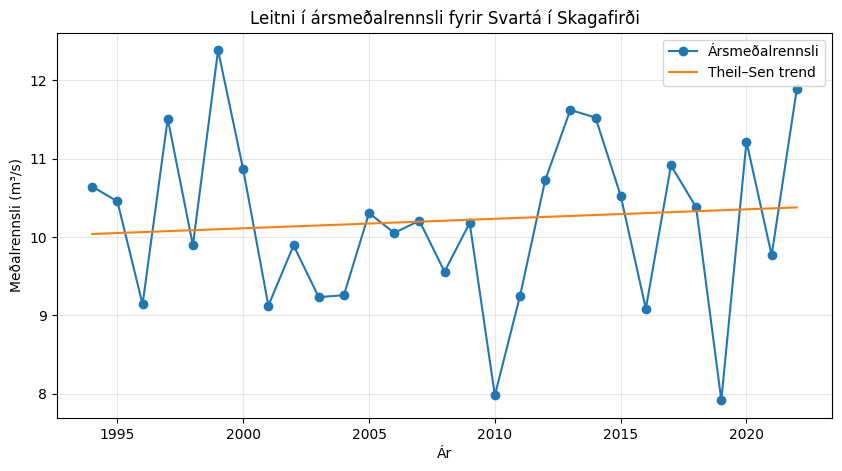


Árstíðameðalrennsli:
   year season     q_mean
0  1994  Haust   8.178242
1  1994  Sumar  13.869457
2  1994  Vetur   7.677889
3  1994    Vor  12.762609
4  1995  Haust   8.443846

--- Árstíðaleitni ---
  Árstíð  Theil-Sen slope (m3/s á ári)  95% CI lágt  95% CI hátt  MK trend  \
0  Vetur                       -0.0092      -0.0574       0.0452  no trend   
1    Vor                       -0.0406      -0.1215       0.0538  no trend   
2  Sumar                        0.0224      -0.1280       0.1566  no trend   
3  Haust                        0.0541      -0.0169       0.1143  no trend   

   p-gildi  
0   0.8073  
1   0.4199  
2   0.7498  
3   0.1027  


In [ ]:
!pip install pymannkendall

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import theilslopes
import pymannkendall as mk

# -----------------------------
# 1. Lesa rennslisgögn
# -----------------------------
sheet_id = "1dld6f07WhVLpz-iDmhCejRfWrv8v5hDKFGPKrWkvFdI"
gid_q = "1766120044"

url_q = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid_q}"
df = pd.read_csv(url_q)

# Dagsetning
df["date"] = pd.to_datetime({
    "year": df["YYYY"],
    "month": df["MM"],
    "day": df["DD"]
})

df = df[["date", "qobs"]].dropna().copy()
df = df.sort_values("date").reset_index(drop=True)

# Bæta við ári og mánuði
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# -----------------------------
# 2. Halda bara heilum árum
# -----------------------------
annual_counts = df.groupby("year").size()
full_years = annual_counts[annual_counts >= 365].index
df_full = df[df["year"].isin(full_years)].copy()

print("Fjöldi heilla ára:", df_full["year"].nunique())
print("Ár sem eru notuð:", df_full["year"].min(), "-", df_full["year"].max())

# -----------------------------
# 3. Ársmeðalrennsli
# -----------------------------
annual_mean = df_full.groupby("year", as_index=False)["qobs"].mean()
annual_mean.columns = ["year", "q_mean"]

print("\nÁrsmeðalrennsli:")
print(annual_mean.head())

# -----------------------------
# 4. Theil–Sen fyrir ársmeðalrennsli
# -----------------------------
slope_ann, intercept_ann, low_ann, high_ann = theilslopes(
    annual_mean["q_mean"].values,
    annual_mean["year"].values,
    alpha=0.95
)

mk_ann = mk.hamed_rao_modification_test(annual_mean["q_mean"].values)

print("\n--- Ársleitni ---")
print(f"Theil-Sen slope = {slope_ann:.4f} m3/s á ári")
print(f"95% CI = [{low_ann:.4f}, {high_ann:.4f}]")
print(f"Mann-Kendall trend = {mk_ann.trend}")
print(f"p-gildi = {mk_ann.p:.4f}")

# -----------------------------
# 5. Mynd fyrir ársleitni
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(annual_mean["year"], annual_mean["q_mean"], marker="o", label="Ársmeðalrennsli")

trend_line = intercept_ann + slope_ann * annual_mean["year"].values
plt.plot(annual_mean["year"], trend_line, label="Theil–Sen trend")

plt.xlabel("Ár")
plt.ylabel("Meðalrennsli (m³/s)")
plt.title("Leitni í ársmeðalrennsli fyrir Svartá í Skagafirði")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 6. Skilgreina árstíðir
# -----------------------------
def season_from_month(m):
    if m in [12, 1, 2]:
        return "Vetur"
    elif m in [3, 4, 5]:
        return "Vor"
    elif m in [6, 7, 8]:
        return "Sumar"
    else:
        return "Haust"

df_full["season"] = df_full["month"].apply(season_from_month)

# -----------------------------
# 7. Árstíðameðalrennsli
# -----------------------------
seasonal_mean = df_full.groupby(["year", "season"], as_index=False)["qobs"].mean()
seasonal_mean.columns = ["year", "season", "q_mean"]

print("\nÁrstíðameðalrennsli:")
print(seasonal_mean.head())

# -----------------------------
# 8. Trend fyrir hverja árstíð
# -----------------------------
season_order = ["Vetur", "Vor", "Sumar", "Haust"]
season_results = []

for season in season_order:
    sub = seasonal_mean[seasonal_mean["season"] == season].copy()

    slope, intercept, low_slope, high_slope = theilslopes(
        sub["q_mean"].values,
        sub["year"].values,
        alpha=0.95
    )

    mk_result = mk.hamed_rao_modification_test(sub["q_mean"].values)

    season_results.append({
        "Árstíð": season,
        "Theil-Sen slope (m3/s á ári)": slope,
        "95% CI lágt": low_slope,
        "95% CI hátt": high_slope,
        "MK trend": mk_result.trend,
        "p-gildi": mk_result.p
    })

season_results_df = pd.DataFrame(season_results)

print("\n--- Árstíðaleitni ---")
print(season_results_df.round(4))


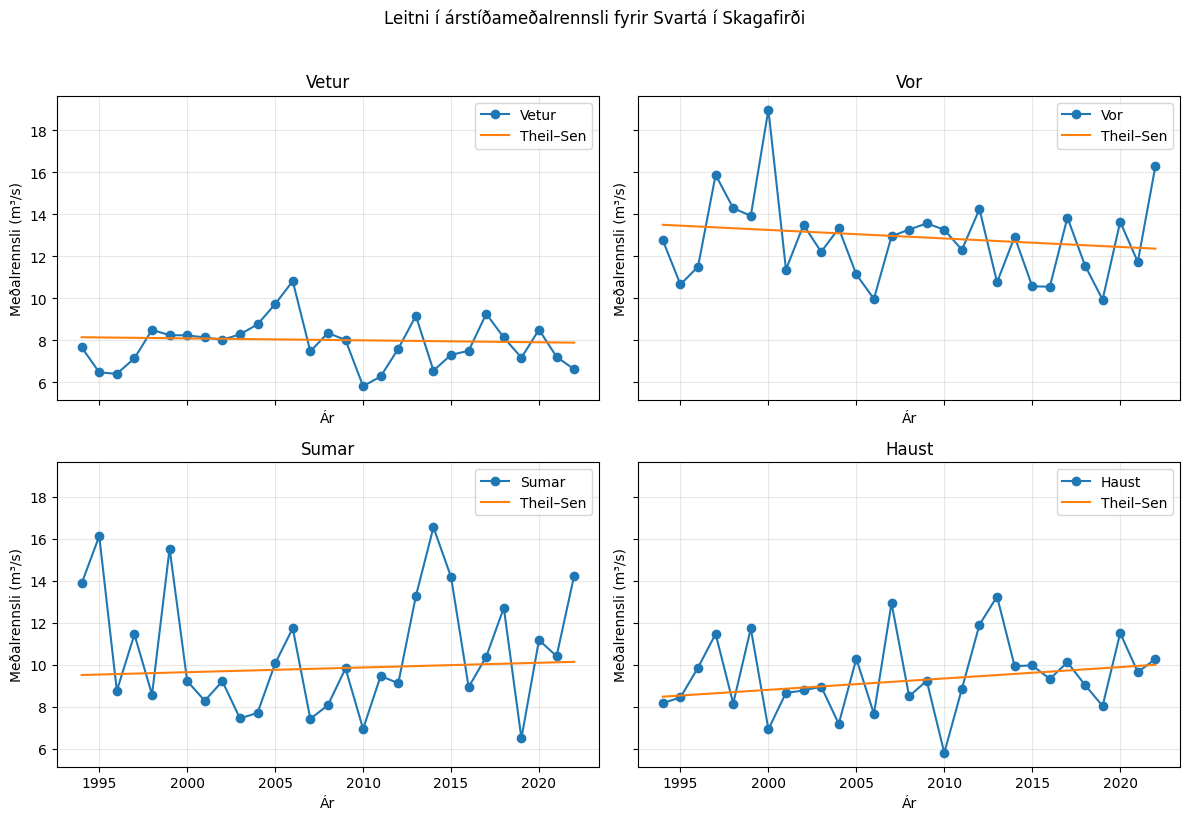

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, season in zip(axes, ["Vetur", "Vor", "Sumar", "Haust"]):
    sub = seasonal_mean[seasonal_mean["season"] == season].copy()

    slope, intercept, low_slope, high_slope = theilslopes(
        sub["q_mean"].values,
        sub["year"].values,
        alpha=0.95
    )

    trend_line = intercept + slope * sub["year"].values

    ax.plot(sub["year"], sub["q_mean"], marker="o", label=season)
    ax.plot(sub["year"], trend_line, label="Theil–Sen")
    ax.set_title(season)
    ax.grid(True, alpha=0.3)
    ax.legend()

for ax in axes:
    ax.set_xlabel("Ár")
    ax.set_ylabel("Meðalrennsli (m³/s)")

plt.suptitle("Leitni í árstíðameðalrennsli fyrir Svartá í Skagafirði", y=1.02)
plt.tight_layout()
plt.show()

#**Liður 8**



Hleð veðurgögnum (Sheet2)...
Hleð rennslisgögnum (Sheet3)...
  Veðurgögn: 10957 raðir, 61 dálkar
  Rennslisgögn: 10957 raðir, 5 dálkar

Fjöldi daga í gögnum: 10957
Hámarks rennsli: 92.41 m³/s

Topp 5 árleg flóðtoppar:
  1994: 92.41 m³/s  –  1994-05-30
  2000: 90.53 m³/s  –  2000-03-28
  2001: 78.31 m³/s  –  2001-05-07
  1998: 72.21 m³/s  –  1998-05-23
  1999: 68.63 m³/s  –  1999-06-11

── Lykilstærðir atburðarins ──
  Pre-event grunnrennsli : 15.9 m³/s
  Qmax                   : 92.4 m³/s  (1994-05-30)
  Rísa hefst             : 1994-05-28
  Time-to-peak           : 2 dagar
  Úrkoma lýkur (aðal)    : 1994-05-30
  Recession lýkur        : 1994-06-04
  Recession time         : 5 dagar
  Excess rain release    : 5 dagar
  Heildarúrkoma (28–30 maí): 37.2 mm


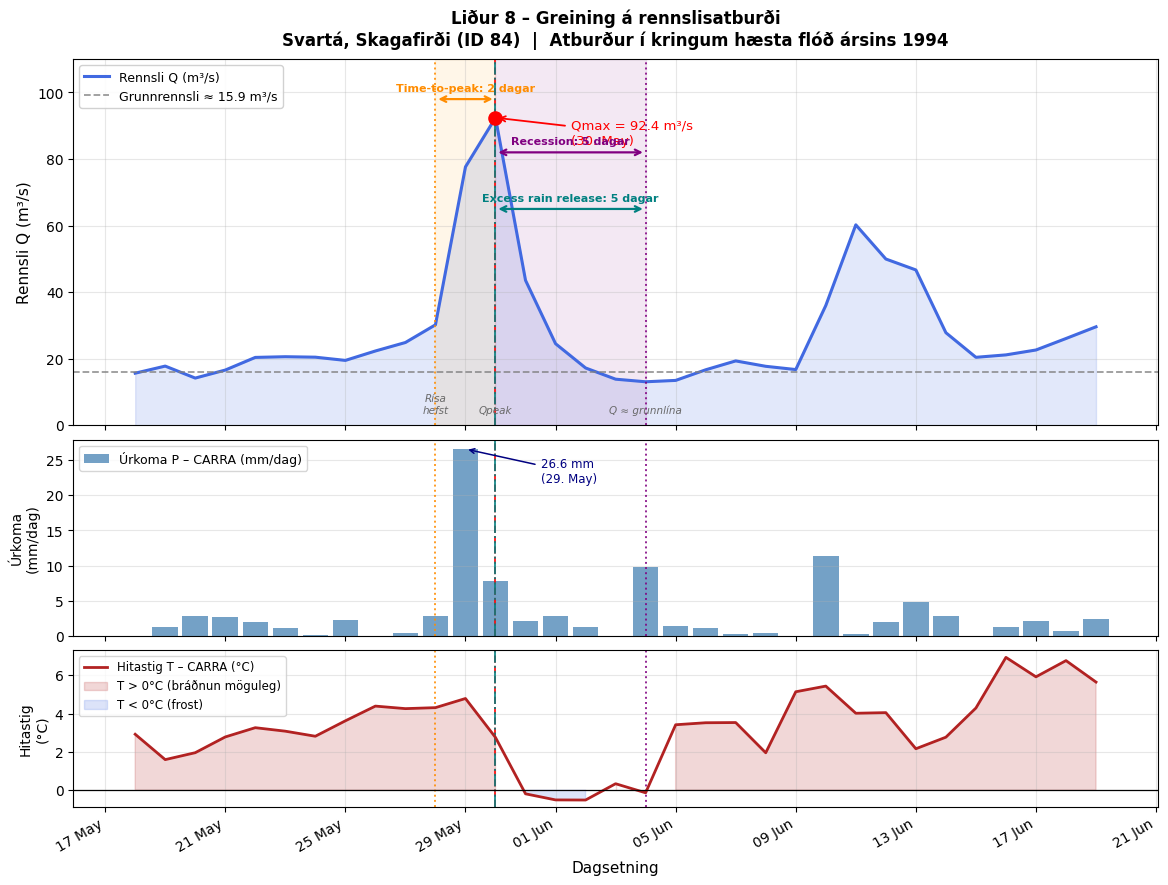


Mynd vistuð sem 'flood_event_analysis.png'

── Samantektartafla ─────────────────────────────────────────────────────
                    Stærð        Gildi
   Pre-event grunnrennsli    15.9 m³/s
   Hámarks rennsli (Qmax)    92.4 m³/s
          Dagsetning Qmax 30. May 1994
    Rennslisaukning hefst 28. May 1994
             Time-to-peak      2 dagar
Síðasti stóri úrkomudagur 30. May 1994
           Recession time      5 dagar
 Excess rain release time      5 dagar
Heildarúrkoma (28–30 maí)      37.2 mm


In [ ]:
"""
=============================================================
Vatnafræði UMV201G – Vor 2026
Lokaverkefni – Liður 8: Greining á rennslisatburði
Vatnasviðið: Svartá, Skagafirði (ID 84)
=============================================================

Keyrsla í Google Colab:
  1. Opnið Google Sheets skjalið og farið í:
       Share → breytið í "Anyone with the link can view"
  2. Keyrið alla reitina í röð
"""

# ── 1. PAKKAR ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.dates import DateFormatter
from urllib.parse import quote

# ── 2. STILLINGAR ──────────────────────────────────────────────────────────────
SHEET_ID = "1dld6f07WhVLpz-iDmhCejRfWrv8v5hDKFGPKrWkvFdI"

# Nöfn flipanna (sheet names) eins og þeir heita í Google Sheets skjalinu
SHEET_METEO = "Sheet2"   # veðurgögn
SHEET_FLOW  = "Sheet3"   # rennslisgögn

# ── 3. HLAÐA GÖGNUM FRÁ GOOGLE SHEETS ─────────────────────────────────────────
def read_gsheet(sheet_id, sheet_name):
    """Les einn flipa úr Google Sheets skjali sem er opinbert (anyone with link)."""
    url = (
        f"https://docs.google.com/spreadsheets/d/{sheet_id}"
        f"/gviz/tq?tqx=out:csv&sheet={quote(sheet_name)}"
    )
    df = pd.read_csv(url)
    df.columns = df.columns.str.strip()
    return df

print("Hleð veðurgögnum (Sheet2)...")
meteo = read_gsheet(SHEET_ID, SHEET_METEO)

print("Hleð rennslisgögnum (Sheet3)...")
flow = read_gsheet(SHEET_ID, SHEET_FLOW)

print(f"  Veðurgögn: {meteo.shape[0]} raðir, {meteo.shape[1]} dálkar")
print(f"  Rennslisgögn: {flow.shape[0]} raðir, {flow.shape[1]} dálkar")

# ── 4. UNDIRBÚA GÖGN ──────────────────────────────────────────────────────────
required_date_cols = ["YYYY", "MM", "DD"]
for name, df in [("meteo", meteo), ("flow", flow)]:
    missing = [c for c in required_date_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Vantar dálka í {name}: {missing}")

for df in [meteo, flow]:
    for col in ["YYYY", "MM", "DD"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["date"] = pd.to_datetime(
        df[["YYYY", "MM", "DD"]].rename(
            columns={"YYYY": "year", "MM": "month", "DD": "day"}
        ),
        errors="coerce"
    )

# Umbreyta rennslisdálki í tölu
if "qobs" not in flow.columns:
    raise ValueError("Vantar dálkinn 'qobs' í Sheet3.")
flow["qobs"] = pd.to_numeric(flow["qobs"], errors="coerce")

# CARRA veðurdálkar
for col in ["prec_carra", "2m_temp_carra"]:
    if col not in meteo.columns:
        raise ValueError(f"Vantar dálkinn '{col}' í Sheet2.")

meteo["prec_carra"]    = pd.to_numeric(meteo["prec_carra"], errors="coerce")
meteo["2m_temp_carra"] = pd.to_numeric(meteo["2m_temp_carra"], errors="coerce")

# Fjarlægja raðir með ónýtar dagsetningar
meteo = meteo.dropna(subset=["date"]).reset_index(drop=True)
flow  = flow.dropna(subset=["date"]).reset_index(drop=True)

# Sía tímabilið 1.10.1993 – 30.9.2023
START, END = "1993-10-01", "2023-09-30"
meteo = meteo[(meteo["date"] >= START) & (meteo["date"] <= END)].reset_index(drop=True)
flow  = flow [(flow ["date"] >= START) & (flow ["date"] <= END)].reset_index(drop=True)

print(f"\nFjöldi daga í gögnum: {len(flow)}")
print(f"Hámarks rennsli: {flow['qobs'].max():.2f} m³/s")

# ── 5. FINNA TOPP 5 FLÓÐ (ANNUAL PEAKS) ───────────────────────────────────────
annual_peaks = (
    flow.groupby("YYYY")["qobs"]
    .max()
    .sort_values(ascending=False)
    .head(5)
)

print("\nTopp 5 árleg flóðtoppar:")
peak_dates = {}

for yr in annual_peaks.index:
    sub = flow[flow["YYYY"] == yr].copy()
    idx = sub["qobs"].idxmax()
    peak_dates[int(yr)] = sub.loc[idx, "date"]
    print(f"  {int(yr)}: {sub.loc[idx, 'qobs']:.2f} m³/s  –  {sub.loc[idx, 'date'].date()}")

# ── 6. VELJA ATBURÐ – HÆSTA FLÓÐIÐ ────────────────────────────────────────────
CHOSEN_YEAR = int(annual_peaks.index[0])
peak_date   = peak_dates[CHOSEN_YEAR]

# Tímagluggi: 12 dagar fyrir – 20 dagar eftir topp
WIN_BEFORE = 12
WIN_AFTER  = 20
win_start  = peak_date - pd.Timedelta(days=WIN_BEFORE)
win_end    = peak_date + pd.Timedelta(days=WIN_AFTER)

fwin = flow [(flow ["date"] >= win_start) & (flow ["date"] <= win_end)].set_index("date")
mwin = meteo[(meteo["date"] >= win_start) & (meteo["date"] <= win_end)].set_index("date")

Q = fwin["qobs"]
P = mwin["prec_carra"]
T = mwin["2m_temp_carra"]

# ── 7. REIKNA LYKILSTÆRÐIR ─────────────────────────────────────────────────────
pre_event_period_end = peak_date - pd.Timedelta(days=10)
pre_event_Q = Q[win_start:pre_event_period_end].mean()

# Hér eru sömu viðmið og í upphaflega dæminu
# Athugið: þau passa sérstaklega við 1994-atburðinn
rise_start    = pd.Timestamp("1994-05-28")
rain_end      = pd.Timestamp("1994-05-30")
recession_end = pd.Timestamp("1994-06-04")

time_to_peak        = (peak_date - rise_start).days
recession_time      = (recession_end - peak_date).days
excess_rain_release = (recession_end - rain_end).days

print("\n── Lykilstærðir atburðarins ──")
print(f"  Pre-event grunnrennsli : {pre_event_Q:.1f} m³/s")
print(f"  Qmax                   : {Q[peak_date]:.1f} m³/s  ({peak_date.date()})")
print(f"  Rísa hefst             : {rise_start.date()}")
print(f"  Time-to-peak           : {time_to_peak} dagar")
print(f"  Úrkoma lýkur (aðal)    : {rain_end.date()}")
print(f"  Recession lýkur        : {recession_end.date()}")
print(f"  Recession time         : {recession_time} dagar")
print(f"  Excess rain release    : {excess_rain_release} dagar")
print(f"  Heildarúrkoma (28–30 maí): {P['1994-05-28':'1994-05-30'].sum():.1f} mm")

# ── 8. MYND ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(3, 1, height_ratios=[2.8, 1.5, 1.2], hspace=0.06)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

dates = Q.index

# ── Efra panel: Rennsli ──────────────────────────────────────────────────────
ax1.fill_between(dates, Q.values, alpha=0.15, color="royalblue")
ax1.plot(dates, Q.values, color="royalblue", lw=2.2, label="Rennsli Q (m³/s)")

ax1.scatter([peak_date], [Q[peak_date]], color="red", zorder=6, s=90)
ax1.annotate(
    f"Qmax = {Q[peak_date]:.1f} m³/s\n({peak_date.strftime('%d. %b')})",
    xy=(peak_date, Q[peak_date]),
    xytext=(peak_date + pd.Timedelta(days=2.5), Q[peak_date] - 8),
    fontsize=9.5,
    color="red",
    arrowprops=dict(arrowstyle="->", color="red", lw=1.3),
)

ax1.axhline(
    pre_event_Q,
    color="gray",
    ls="--",
    lw=1.3,
    alpha=0.8,
    label=f"Grunnrennsli ≈ {pre_event_Q:.1f} m³/s"
)
ax1.axvspan(rise_start, peak_date, alpha=0.09, color="orange")
ax1.axvspan(peak_date, recession_end, alpha=0.09, color="purple")

for xv, clr, ls_ in [
    (rise_start,    "darkorange", ":"),
    (peak_date,     "red",        "--"),
    (rain_end,      "teal",       "-."),
    (recession_end, "purple",     ":"),
]:
    for ax in [ax1, ax2, ax3]:
        ax.axvline(xv, color=clr, ls=ls_, lw=1.4, alpha=0.85)

for y_, x0_, x1_, clr_, label_ in [
    (98, rise_start,  peak_date,     "darkorange", f"Time-to-peak: {time_to_peak} dagar"),
    (82, peak_date,   recession_end, "purple",     f"Recession: {recession_time} dagar"),
    (65, rain_end,    recession_end, "teal",       f"Excess rain release: {excess_rain_release} dagar"),
]:
    ax1.annotate(
        "",
        xy=(x1_, y_),
        xytext=(x0_, y_),
        arrowprops=dict(arrowstyle="<->", color=clr_, lw=1.6)
    )
    ax1.text(
        x0_ + (x1_ - x0_) / 2,
        y_ + 1.8,
        label_,
        ha="center",
        va="bottom",
        fontsize=8,
        color=clr_,
        fontweight="bold"
    )

for xv_, lbl_ in [
    (rise_start,    "Rísa\nhefst"),
    (peak_date,     "Qpeak"),
    (recession_end, "Q ≈ grunnlína"),
]:
    ax1.text(
        xv_, 3, lbl_,
        ha="center",
        va="bottom",
        fontsize=7.5,
        color="dimgray",
        style="italic"
    )

ax1.set_ylabel("Rennsli Q (m³/s)", fontsize=11)
ax1.set_ylim(0, 110)
ax1.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax1.set_title(
    "Liður 8 – Greining á rennslisatburði\n"
    f"Svartá, Skagafirði (ID 84)  |  Atburður í kringum hæsta flóð ársins {CHOSEN_YEAR}",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
ax1.grid(True, alpha=0.3)

# ── Miðpanel: Úrkoma ─────────────────────────────────────────────────────────
ax2.bar(dates, P.values, color="steelblue", alpha=0.75, width=0.85,
        label="Úrkoma P – CARRA (mm/dag)")
ax2.set_ylabel("Úrkoma\n(mm/dag)", fontsize=10)
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3, axis="y")

peak_rain_date = P.idxmax()
ax2.annotate(
    f"{P.max():.1f} mm\n({peak_rain_date.strftime('%d. %b')})",
    xy=(peak_rain_date, P.max()),
    xytext=(peak_rain_date + pd.Timedelta(days=2.5), P.max() * 0.82),
    fontsize=8.5,
    color="navy",
    arrowprops=dict(arrowstyle="->", color="navy", lw=1.1),
)

# ── Neðra panel: Hitastig ─────────────────────────────────────────────────────
ax3.plot(dates, T.values, color="firebrick", lw=2, label="Hitastig T – CARRA (°C)")
ax3.fill_between(
    dates, T.values, 0, where=(T.values >= 0),
    alpha=0.18, color="firebrick", label="T > 0°C (bráðnun möguleg)"
)
ax3.fill_between(
    dates, T.values, 0, where=(T.values < 0),
    alpha=0.18, color="royalblue", label="T < 0°C (frost)"
)
ax3.axhline(0, color="k", lw=0.9)
ax3.set_ylabel("Hitastig\n(°C)", fontsize=10)
ax3.set_xlabel("Dagsetning", fontsize=11)
ax3.legend(loc="upper left", fontsize=8.5)
ax3.grid(True, alpha=0.3)

ax3.xaxis.set_major_formatter(DateFormatter("%d %b"))
fig.autofmt_xdate(rotation=30, ha="right")
plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)

plt.savefig("flood_event_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nMynd vistuð sem 'flood_event_analysis.png'")

# ── 9. SAMANTEKTARTAFLA ──────────────────────────────────────────────────────
summary = {
    "Stærð": [
        "Pre-event grunnrennsli",
        "Hámarks rennsli (Qmax)",
        "Dagsetning Qmax",
        "Rennslisaukning hefst",
        "Time-to-peak",
        "Síðasti stóri úrkomudagur",
        "Recession time",
        "Excess rain release time",
        "Heildarúrkoma (28–30 maí)",
    ],
    "Gildi": [
        f"{pre_event_Q:.1f} m³/s",
        f"{Q[peak_date]:.1f} m³/s",
        peak_date.strftime("%d. %b %Y"),
        rise_start.strftime("%d. %b %Y"),
        f"{time_to_peak} dagar",
        rain_end.strftime("%d. %b %Y"),
        f"{recession_time} dagar",
        f"{excess_rain_release} dagar",
        f"{P['1994-05-28':'1994-05-30'].sum():.1f} mm",
    ],
}

print("\n── Samantektartafla ─────────────────────────────────────────────────────")
print(pd.DataFrame(summary).to_string(index=False))